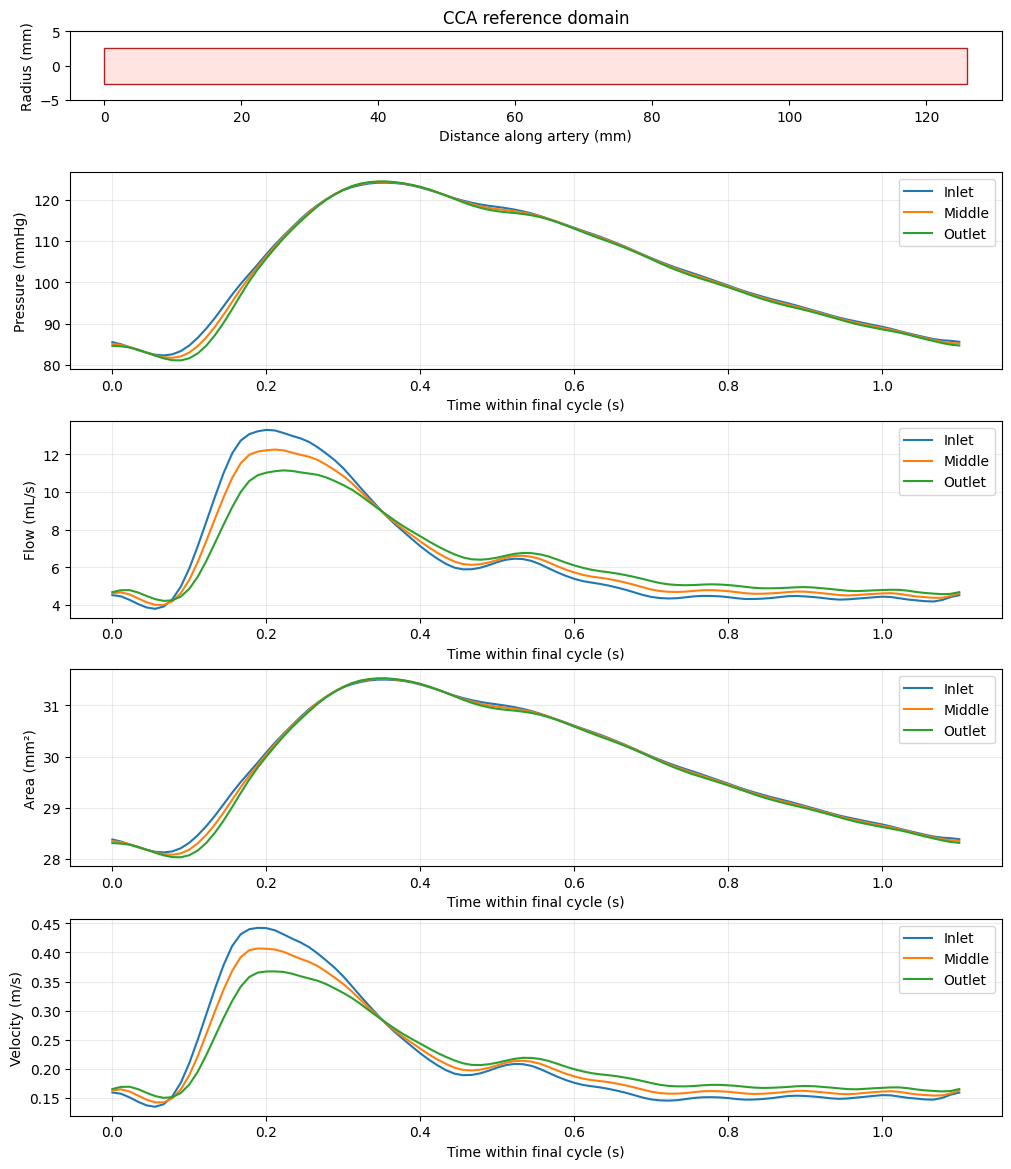

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

results = Path("../cca_results")
vessel = "common_carotid_artery"

fig, axes = plt.subplots(5, 1, figsize=(10, 12), constrained_layout=True)

# Reference geometry: a schematic of the 1D domain.
ax = axes[0]
ax.add_patch(Rectangle((0, -2.6485), 126, 5.297,
                       facecolor="mistyrose", edgecolor="firebrick"))
ax.set(xlim=(-5, 131), ylim=(-5, 5),
       xlabel="Distance along artery (mm)", ylabel="Radius (mm)",
       title="CCA reference domain")
ax.set_aspect("equal", adjustable="box")

fields = [
    ("P", 1 / 133.322, "Pressure (mmHg)"),
    ("Q", 1e6, "Flow (mL/s)"),
    ("A", 1e6, "Area (mm²)"),
    ("u", 1, "Velocity (m/s)"),
]

for ax, (field, factor, ylabel) in zip(axes[1:], fields):
    data = np.loadtxt(results / f"{vessel}_{field}.last")
    time = data[:, 0] - data[0, 0]
    for column, label in [(1, "Inlet"), (3, "Middle"), (5, "Outlet")]:
        ax.plot(time, data[:, column] * factor, label=label)
    ax.set(xlabel="Time within final cycle (s)", ylabel=ylabel)
    ax.grid(alpha=0.25)
    ax.legend()

fig.savefig(results / "cca_visualization.png", dpi=200)
plt.show()

## CCA centerline mesh

Exports the straight model centerline with one segment per solver cell. Coordinates and reference radii in the VTP are in metres; the plot displays millimetres.

If PyVista is missing in this kernel, run `%pip install pyvista` once. The plot uses PyVista's static notebook backend. For a separate interactive window, set `notebook=False, off_screen=False` and use `plotter.show()`.


Saved c:\DATA\dev\openBFpy\cca_results\cca_centerline.vtp: 127 points, 126 segments


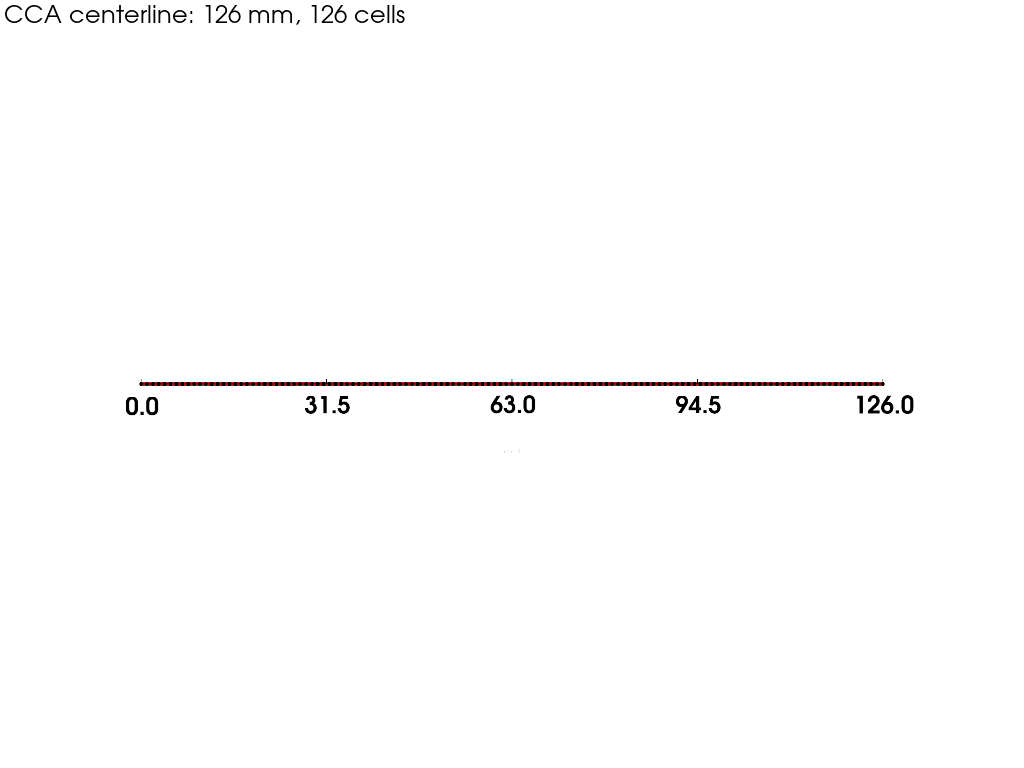

In [4]:
from pathlib import Path
import sys
import numpy as np
import yaml
import pyvista as pv

# Locate the project from either the root or scripts directory.
root = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "openbfpy" / "vessel.py").is_file()),
    None,
)
if root is None:
    raise FileNotFoundError("Start the notebook from inside the openBFpy project.")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from openbfpy.vessel import Blood, Vessel

config_path = root / "openBF/models/boileau2015/cca/cca.yaml"
with config_path.open(encoding="utf-8") as stream:
    config = yaml.safe_load(stream)
vessel_config = next(
    item for item in config["network"]
    if item["label"] == "common_carotid_artery"
)
cca = Vessel(vessel_config, Blood(**config["blood"]))

# Faces bound solver cells; their midpoints match cca.x.
x_faces = np.linspace(0.0, cca.L, cca.M + 1)
points = np.column_stack((x_faces, np.zeros_like(x_faces), np.zeros_like(x_faces)))
indices = np.arange(cca.M, dtype=np.int64)
lines = np.column_stack((np.full(cca.M, 2), indices, indices + 1)).ravel()
centerline = pv.PolyData(points, lines=lines)
rp = vessel_config.get("Rp", vessel_config.get("R0"))
rd = vessel_config.get("Rd", rp)
centerline.point_data["radius_m"] = rp + (rd - rp) * x_faces / cca.L
centerline.point_data["distance_m"] = x_faces
centerline.cell_data["cell_center_m"] = cca.x

output_dir = root / "cca_results"
output_dir.mkdir(parents=True, exist_ok=True)
vtp_path = output_dir / "cca_centerline.vtp"
centerline.save(vtp_path)
print(f"Saved {vtp_path}: {centerline.n_points} points, {centerline.n_lines} segments")

# Reload the file; display coordinates in mm while the saved file uses metres.
saved_centerline = pv.read(vtp_path)
plot_mesh = saved_centerline.copy()
plot_mesh.points *= 1e3
plotter = pv.Plotter(notebook=True, off_screen=True)
plotter.add_mesh(plot_mesh, color="firebrick", line_width=4)
plotter.add_mesh(pv.PolyData(plot_mesh.points), color="black", point_size=4)
plotter.add_text(f"CCA centerline: {cca.L * 1e3:g} mm, {cca.M} cells", font_size=12)
plotter.show_bounds(xtitle="x (mm)", ytitle="y (mm)", ztitle="z (mm)")
plotter.view_xy()
plotter.show(jupyter_backend="static")
